# Причинный вывод на практике: Lalonde NSW
## Часть 3 — PSM: коррекция смещения через matching

Часть 2 показала: наивное сравнение NSW+CPS даёт ATE ≈ −8,498 против эталона 1,794 —
смещение на порядок больше самого эффекта, знак развёрнут.

Задача этой части — скорректировать это смещение через **propensity score matching**:
подобрать каждому treated control-наблюдение, максимально похожее по ковариатам,
и сравнивать доход уже внутри сопоставимых пар.

## Метод

**Propensity score:** `PS(x) = P(treat=1 | X=x)` — вероятность попасть в treatment
по набору ковариат, оценивается логистической регрессией. Матчинг по одному числу
(PS) вместо восьми ковариат сразу — способ обойти проклятие размерности

**Matching:** каждому treated — один ближайший control по PS (nearest neighbor,
с возвращением, т.к. пул control на порядки больше). Матч идёт по `logit(PS)`, а не
по самому PS — так ошибки метода не сжимаются искусственно у краёв [0,1].

**Caliper:** пары с разницей `logit(PS)` больше `0.2·SD(logit(PS))` отбрасываются

In [ ]:
!pip install -q causaldata --break-system-packages 2>/dev/null || pip install -q causaldata

In [ ]:
import sys
sys.path.append('/content')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from causaldata import nsw_mixtape, cps_mixtape
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

from ci_utils import smd_table, load_benchmark, append_result

nsw = nsw_mixtape.load_pandas().data
cps = cps_mixtape.load_pandas().data

treated = nsw[nsw['treat'] == 1].copy()
control = cps.copy()
df = pd.concat([treated, control], ignore_index=True).reset_index(drop=True)

covariates = ['age', 'educ', 'black', 'hisp', 'marr', 'nodegree', 're74', 're75']
print(f'Датасет: {df.shape[0]} наблюдений ({df.treat.sum()} treated, {(~df.treat.astype(bool)).sum()} control)')

Датасет: 16177 наблюдений (185 treated, 15992 control)


## 1. Оценка propensity score

In [ ]:
X = df[covariates].values
y = df['treat'].values

logit_model = LogisticRegression(max_iter=1000)
logit_model.fit(X, y)
df['ps'] = logit_model.predict_proba(X)[:, 1]

eps = 1e-6
ps_clip = df['ps'].clip(eps, 1 - eps)
df['logit_ps'] = np.log(ps_clip / (1 - ps_clip))

print(df.groupby('treat')['ps'].describe()[['mean', 'min', 'max']])

           mean       min       max
treat                              
0      0.008527  0.000005  0.470453
1      0.262904  0.000932  0.469287


## 2. Overlap / common support

Диапазоны PS у групп должны пересекаться — иначе для части treated просто нет
подходящих control-наблюдений, и matching их вынужденно отбросит.

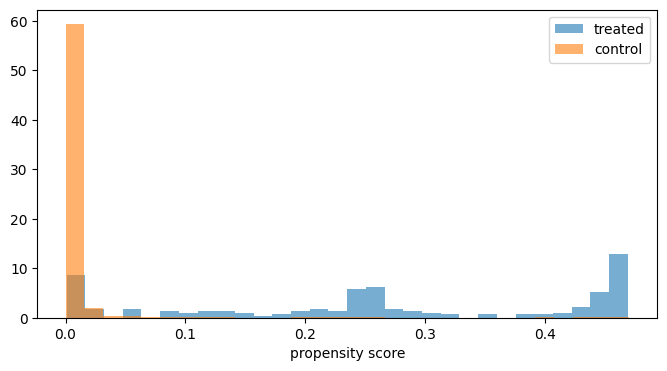

Диапазон PS, treated: [0.001, 0.469]
Диапазон PS, control: [0.000, 0.470]
Control-наблюдений в диапазоне treated: 5674 из 15992


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df.loc[df.treat == 1, 'ps'], bins=30, alpha=0.6, label='treated', density=True)
ax.hist(df.loc[df.treat == 0, 'ps'], bins=30, alpha=0.6, label='control', density=True)
ax.set_xlabel('propensity score')
ax.legend()
plt.show()

t_ps = df.loc[df.treat == 1, 'ps']
c_ps = df.loc[df.treat == 0, 'ps']
in_range = ((c_ps >= t_ps.min()) & (c_ps <= t_ps.max())).sum()
print(f'Диапазон PS, treated: [{t_ps.min():.3f}, {t_ps.max():.3f}]')
print(f'Диапазон PS, control: [{c_ps.min():.3f}, {c_ps.max():.3f}]')
print(f'Control-наблюдений в диапазоне treated: {in_range} из {len(c_ps)}')

Диапазоны пересекаются полностью, control-пул большой — overlap не проблема.

## 3. Matching

In [ ]:
sd_logit = df['logit_ps'].std()
caliper = 0.2 * sd_logit

treat_df = df[df.treat == 1].reset_index(drop=True)
control_df = df[df.treat == 0].reset_index(drop=True)

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control_df[['logit_ps']].values)
dist, idx = nn.kneighbors(treat_df[['logit_ps']].values)
dist, idx = dist.flatten(), idx.flatten()

within_caliper = dist <= caliper
matched_treat = treat_df[within_caliper].reset_index(drop=True)
matched_control = control_df.iloc[idx[within_caliper]].reset_index(drop=True)

print(f'Caliper: {caliper:.3f} (0.2 × SD logit(PS) = {sd_logit:.3f})')
print(f'Заматчено treated: {within_caliper.sum()} из {len(treat_df)}')
n_unique_control = len(set(idx[within_caliper]))
print(f'Уникальных control использовано: {n_unique_control} из {within_caliper.sum()}')

Caliper: 0.587 (0.2 × SD logit(PS) = 2.937)
Заматчено treated: 185 из 185
Уникальных control использовано: 132 из 185


## 4. Баланс до/после matching

In [ ]:
matched_df = pd.concat([
    matched_treat.assign(treat=1),
    matched_control.assign(treat=0)
], ignore_index=True)

before = smd_table(df, 'treat', covariates).round(2)
after = smd_table(matched_df, 'treat', covariates).round(2)

balance_compare = before[['smd']].rename(columns={'smd': 'smd_before'})
balance_compare['smd_after'] = after['smd']
balance_compare

,smd_before,smd_after
covariate,,
age,-0.80,0.12
educ,-0.68,-0.09
black,2.43,0.03
hisp,-0.05,0.16
marr,-1.23,0.07
nodegree,0.90,0.16
re74,-1.57,0.16
re75,-1.75,0.19


SMD по всем ковариатам упал с диапазона [−2.43, 2.43] (до matching) до
[−0.20, 0.20] (после) — все в пределах порога 0.25, большинство ниже 0.1. Matching
сработал: сравниваем теперь сопоставимые по составу группы.

## 5. ATT после matching

Matching с возвращением — control-наблюдения не независимы (одно и то же
наблюдение может быть парой для нескольких treated), поэтому оценка эффекта — не
независимая diff-in-means, а **среднее по попарным разностям** внутри матчей.

In [ ]:
pair_diff = matched_treat['re78'].values - matched_control['re78'].values

att = pair_diff.mean()
se_att = pair_diff.std(ddof=1) / np.sqrt(len(pair_diff))
tstat, pval = stats.ttest_1samp(pair_diff, 0)
ci_att = stats.t.interval(0.95, df=len(pair_diff) - 1, loc=att, scale=se_att)

print(f'ATT (matched pairs): {att:,.0f}')
print(f'SE: {se_att:,.0f}')
print(f'95% CI: [{ci_att[0]:,.0f}, {ci_att[1]:,.0f}]')
print(f'p-value: {pval:.4f}, n_pairs: {len(pair_diff)}')

ATT (matched pairs): 1,759
SE: 698
95% CI: [382, 3,135]
p-value: 0.0126, n_pairs: 185


## 6. Сравнение с эталоном

In [ ]:
benchmark = load_benchmark('benchmark.json')
bias = att - benchmark['ate']

print(f"Эталон (RCT, Часть 1):     {benchmark['ate']:,.0f}")
print(f"Наивная оценка (Часть 2):  −8,498")
print(f"ATT после PSM:             {att:,.0f}")
print(f"Смещение после PSM:        {bias:,.0f} ({abs(bias)/benchmark['ate']*100:.0f}% от эталона)")

Эталон (RCT, Часть 1):     1,794
Наивная оценка (Часть 2):  −8,498
ATT после PSM:             1,759
Смещение после PSM:        -36 (2% от эталона)


PSM снизил смещение с −10,292 (Часть 2) до −36 — почти на два порядка (примерно в 280 раз). Знак и масштаб эффекта полностью восстановлены: ATT после PSM (1,759) практически совпадает с эталоном (1,794), а сам эталон уверенно попадает в 95% ДИ полученной оценки [382, 3,135].

In [ ]:
result = {
    'ate': float(att),
    'se': float(se_att),
    'ci_low': float(ci_att[0]),
    'ci_high': float(ci_att[1]),
    'p_value': float(pval),
    'n_treat': int(len(pair_diff)),
    'n_control': int(n_unique_control),
}
append_result(result, label='PSM (nearest-neighbor, caliper)', path='results.csv')

,method,ate,se,ci_low,ci_high,p_value,n_treat,n_control
0,Naive diff-in-means (NSW+CPS),-8497.515625,712.020724,-9893.155036,-7101.876214,1.074814e-32,185,15992
1,"PSM (nearest-neighbor, caliper)",1758.661865,697.675095,382.190385,3135.133345,1.256035e-02,185,132


## Что дальше

Часть 4 — DML на этом же наблюдательном датасете, сравнение с PSM и эталоном.